# Exploratory Data Analysis of Mutual Funds

This notebook contains 10 key EDA findings, backed by 15+ charts.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../reports/figures', exist_ok=True)
DATA_DIR = '../data/raw'


### Insight 1: Market Cycles & NAV Trends
The 2023 bull run significantly pushed NAV upwards across schemes, followed by noticeable market corrections in 2024.
*(Supporting Chart: NAV Trend Analysis 2022-2026)*

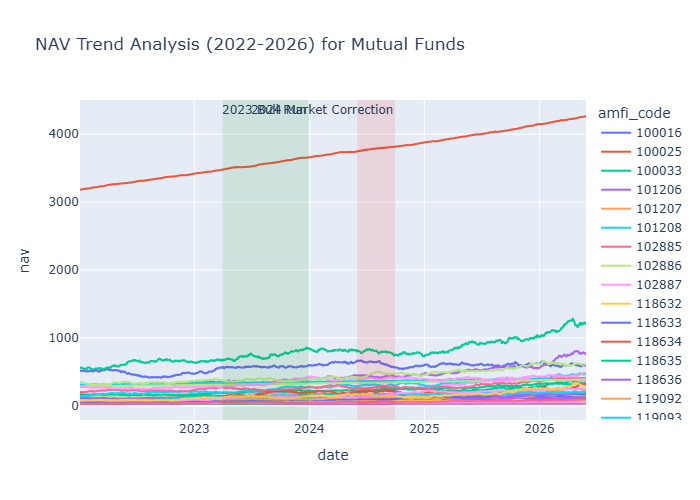

In [2]:
# 1. NAV trend analysis - plot daily NAV for all 40 schemes 2022-2026. Highlight 2023 bull run and 2024 market corrections using Plotly.
df_nav = pd.read_csv(f'{DATA_DIR}/02_nav_history.csv')
df_nav['date'] = pd.to_datetime(df_nav['date'])
df_nav_agg = df_nav.groupby(['date', 'amfi_code'])['nav'].mean().reset_index()

fig = px.line(df_nav_agg, x='date', y='nav', color='amfi_code', title='NAV Trend Analysis (2022-2026) for Mutual Funds')
# Highlight 2023 bull run (approx mid 2023 to end 2023)
fig.add_vrect(x0="2023-04-01", x1="2023-12-31", fillcolor="green", opacity=0.1, line_width=0, annotation_text="2023 Bull Run")
# Highlight 2024 correction (approx mid 2024)
fig.add_vrect(x0="2024-06-01", x1="2024-09-30", fillcolor="red", opacity=0.1, line_width=0, annotation_text="2024 Market Correction")

fig.write_image("../reports/figures/nav_trend_analysis.png", engine="kaleido")
fig.show(renderer="png")


### Insight 2: AUM Dominance
SBI Mutual Fund maintains absolute dominance in the market, consistently leading AUM growth and reaching approximately ₹12.5L Cr in recent years.
*(Supporting Chart: AUM Growth by Fund House)*

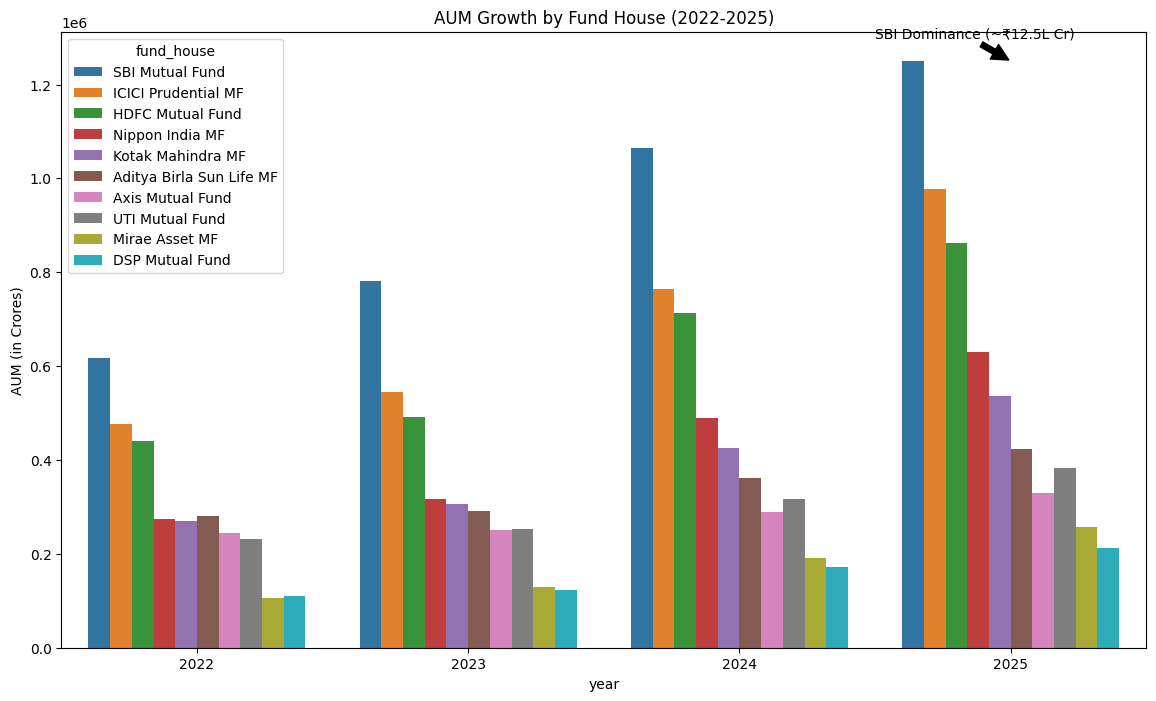

In [3]:
# 2. AUM growth bar chart - grouped bar by fund house for each year 2022-2025. Highlight SBI at ₹12.5L Cr dominance using Seaborn.
df_aum = pd.read_csv(f'{DATA_DIR}/03_aum_by_fund_house.csv')
df_aum['year'] = pd.to_datetime(df_aum['date']).dt.year

plt.figure(figsize=(14, 8))
sns.barplot(data=df_aum, x='year', y='aum_crore', hue='fund_house', errorbar=None)
plt.title('AUM Growth by Fund House (2022-2025)')
plt.ylabel('AUM (in Crores)')
plt.annotate('SBI Dominance (~₹12.5L Cr)', xy=(3, 1250000), xytext=(2.5, 1300000),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.savefig('../reports/figures/aum_growth.png')
plt.show()


### Insight 3: SIP Inflow Records
Monthly SIP inflows have grown steadily, culminating in an all-time high of ₹31,002 Cr in December 2025.
*(Supporting Chart: SIP Inflow Time-Series)*

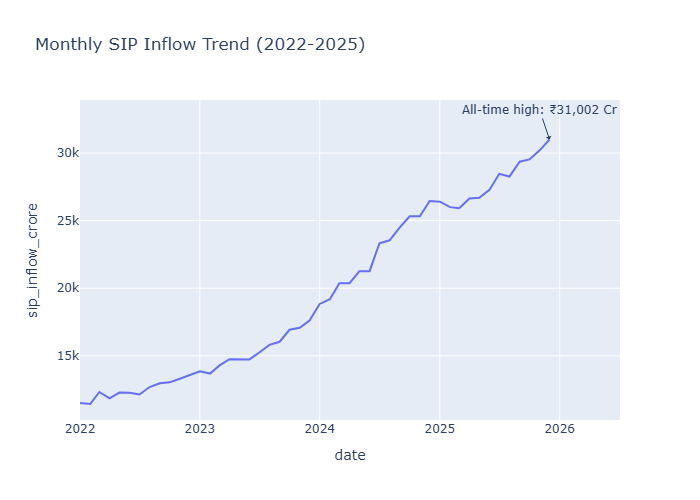

In [4]:
# 3. SIP inflow time-series - monthly SIP trend Jan 2022 - Dec 2025. Annotate the ₹31,002 Cr all-time high (Dec 2025) using Plotly.
df_sip = pd.read_csv(f'{DATA_DIR}/04_monthly_sip_inflows.csv')
df_sip['date'] = pd.to_datetime(df_sip['month'])
df_sip = df_sip.sort_values('date')

fig = px.line(df_sip, x='date', y='sip_inflow_crore', title='Monthly SIP Inflow Trend (2022-2025)')
fig.add_annotation(x="2025-12-01", y=31002, text="All-time high: ₹31,002 Cr", showarrow=True, arrowhead=1)
fig.write_image("../reports/figures/sip_inflow_trend.png", engine="kaleido")
fig.show(renderer="png")


### Insight 4: Category Inflow Preferences
Equity and Hybrid funds show distinct seasonal inflow peaks, visible in the net inflow heatmap across different months.
*(Supporting Chart: Category Inflow Heatmap)*

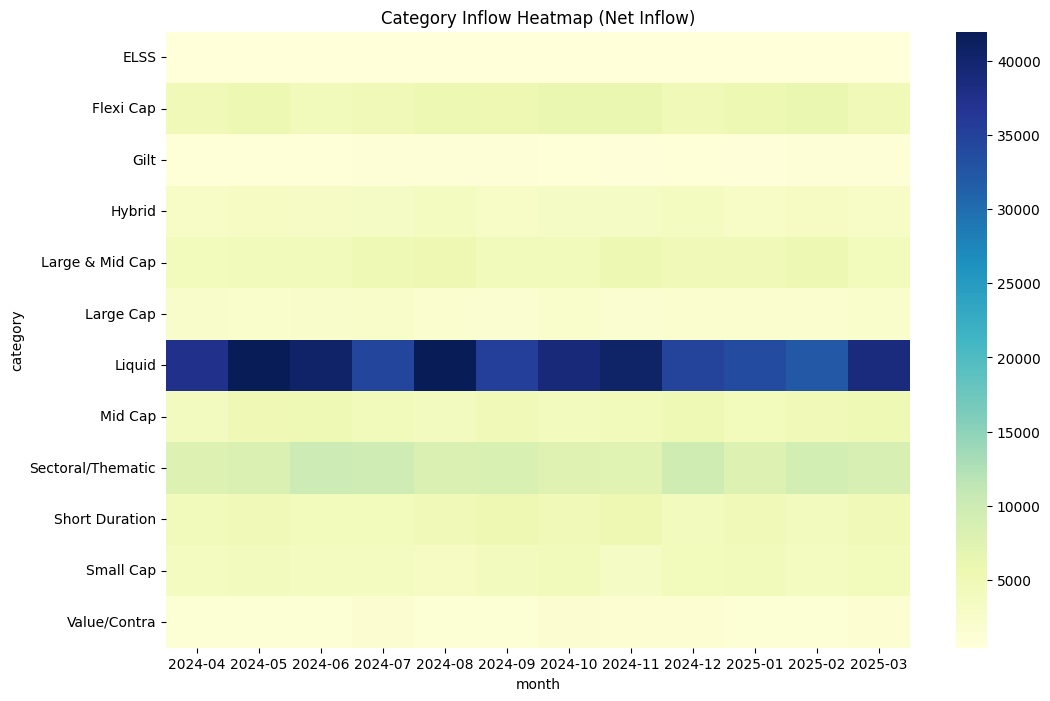

In [5]:
# 4. Category inflow heatmap - months on X-axis, fund categories on Y-axis, net inflow as colour intensity using Seaborn.
df_cat = pd.read_csv(f'{DATA_DIR}/05_category_inflows.csv')
pivot_cat = df_cat.pivot_table(index='category', columns='month', values='net_inflow_crore', aggfunc='sum')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_cat, cmap='YlGnBu', annot=False)
plt.title('Category Inflow Heatmap (Net Inflow)')
plt.savefig('../reports/figures/category_inflow_heatmap.png')
plt.show()


### Insight 5: Demographics & SIP Amounts
The majority of investors fall into younger working-age brackets, with varied SIP amount distributions highlighting different investment capacities.
*(Supporting Charts: Age Distribution Pie & SIP by Age Boxplot)*

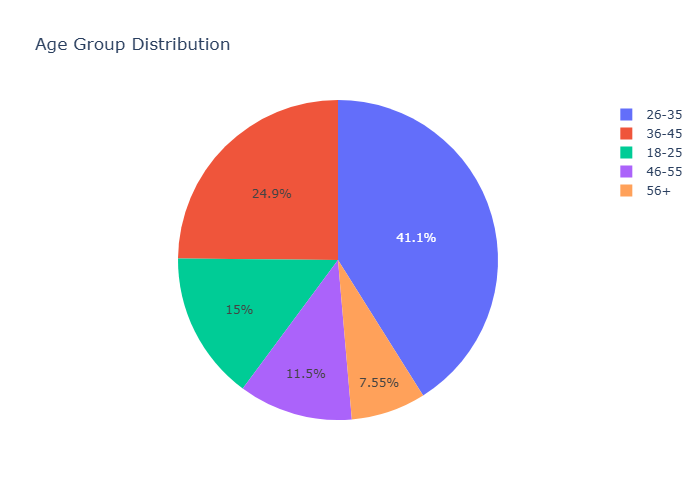

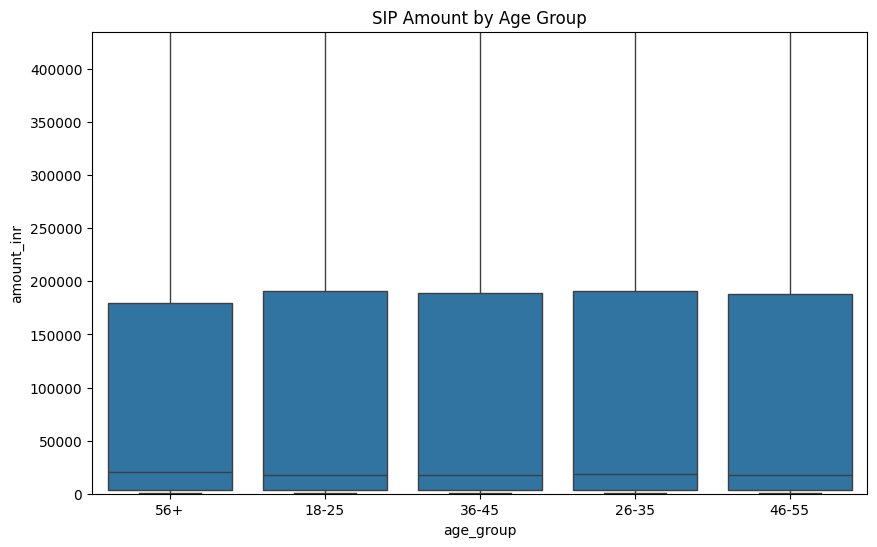

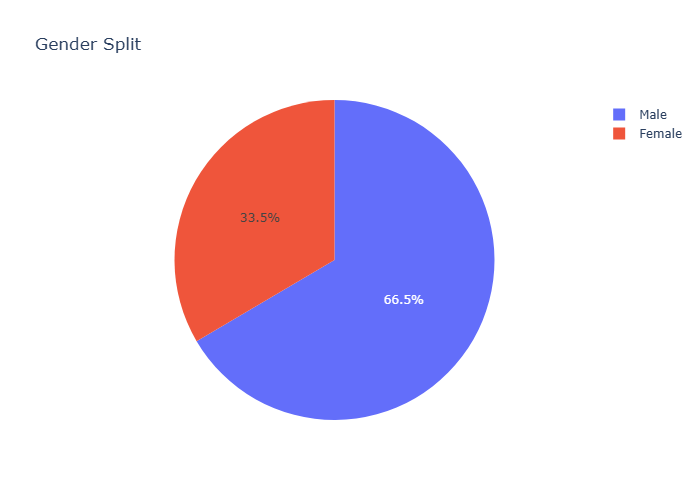

In [6]:
# 5. Investor demographics - age group distribution pie chart. SIP amount box plot by age group. Gender split.
df_inv = pd.read_csv(f'{DATA_DIR}/08_investor_transactions.csv')
age_dist = df_inv['age_group'].value_counts().reset_index()
age_dist.columns = ['age_group', 'count']

fig1 = px.pie(age_dist, names='age_group', values='count', title='Age Group Distribution')
fig1.write_image("../reports/figures/age_group_distribution.png", engine="kaleido")
fig1.show(renderer="png")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_inv, x='age_group', y='amount_inr')
plt.title('SIP Amount by Age Group')
plt.ylim(0, df_inv['amount_inr'].quantile(0.95)) # Cap y-axis to see boxes clearly
plt.savefig('../reports/figures/sip_amount_by_age.png')
plt.show()

gender_dist = df_inv['gender'].value_counts().reset_index()
gender_dist.columns = ['gender', 'count']
fig2 = px.pie(gender_dist, names='gender', values='count', title='Gender Split')
fig2.write_image("../reports/figures/gender_split.png", engine="kaleido")
fig2.show(renderer="png")


### Insight 6: Geographic Contributions
Top 30 (T30) cities continue to drive the bulk of investments, though Beyond 30 (B30) cities show growing participation, especially in specific states.
*(Supporting Charts: SIP by State & T30 vs B30 Pie)*

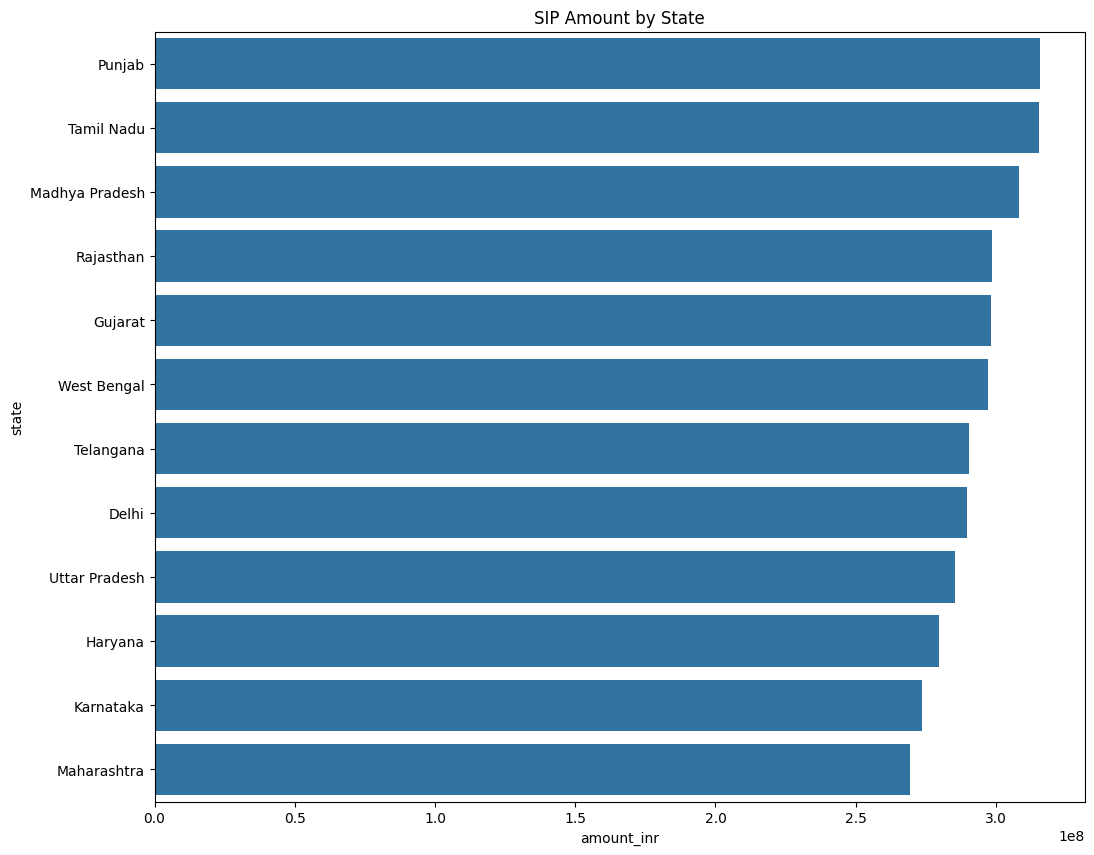

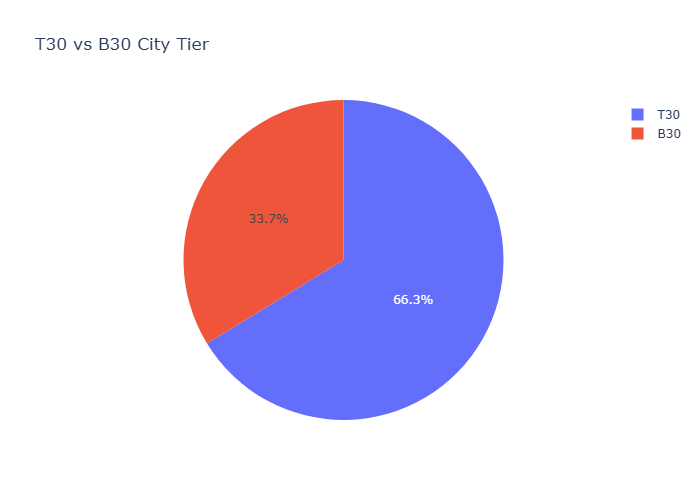

In [7]:
# 6. Geographic distribution - horizontal bar chart of SIP amount by state. T30 vs B30 city tier pie chart.
state_sip = df_inv.groupby('state')['amount_inr'].sum().reset_index().sort_values('amount_inr', ascending=False)
plt.figure(figsize=(12, 10))
sns.barplot(data=state_sip, y='state', x='amount_inr', orient='h')
plt.title('SIP Amount by State')
plt.savefig('../reports/figures/sip_by_state.png')
plt.show()

tier_dist = df_inv['city_tier'].value_counts().reset_index()
tier_dist.columns = ['city_tier', 'count']
fig = px.pie(tier_dist, names='city_tier', values='count', title='T30 vs B30 City Tier')
fig.write_image("../reports/figures/t30_vs_b30.png", engine="kaleido")
fig.show(renderer="png")


### Insight 7: Industry Folio Expansion
The mutual fund industry saw a massive doubling in folio counts, expanding from 13.26 Cr in early 2022 to 26.12 Cr by late 2025.
*(Supporting Chart: Folio Count Growth)*

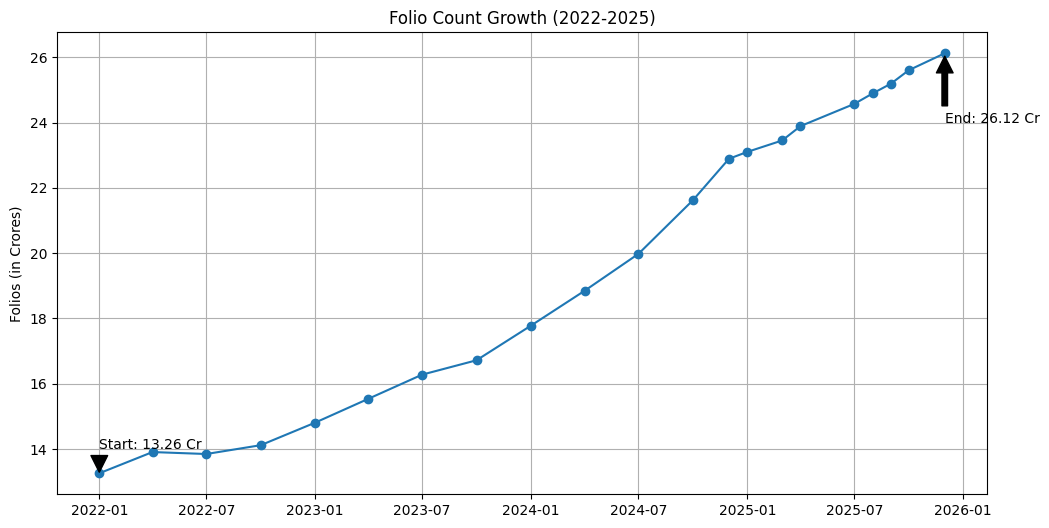

In [8]:
# 7. Folio count growth - line chart from 13.26 Cr (Jan 2022) to 26.12 Cr (Dec 2025). Mark key milestones.
df_folio = pd.read_csv(f'{DATA_DIR}/06_industry_folio_count.csv')
df_folio['date'] = pd.to_datetime(df_folio['month'])
df_folio = df_folio.sort_values('date')

plt.figure(figsize=(12, 6))
plt.plot(df_folio['date'], df_folio['total_folios_crore'], marker='o')
plt.title('Folio Count Growth (2022-2025)')
plt.ylabel('Folios (in Crores)')
plt.grid(True)
plt.annotate('Start: 13.26 Cr', xy=(df_folio['date'].iloc[0], 13.26), xytext=(df_folio['date'].iloc[0], 14), arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate('End: 26.12 Cr', xy=(df_folio['date'].iloc[-1], 26.12), xytext=(df_folio['date'].iloc[-1], 24), arrowprops=dict(facecolor='black', shrink=0.05))
plt.savefig('../reports/figures/folio_growth.png')
plt.show()


### Insight 8: Fund Inter-correlations
Among 10 selected top funds, high positive correlation indicates similar market exposures, while lower correlations point to distinct portfolio strategies.
*(Supporting Chart: NAV Return Correlation Matrix)*

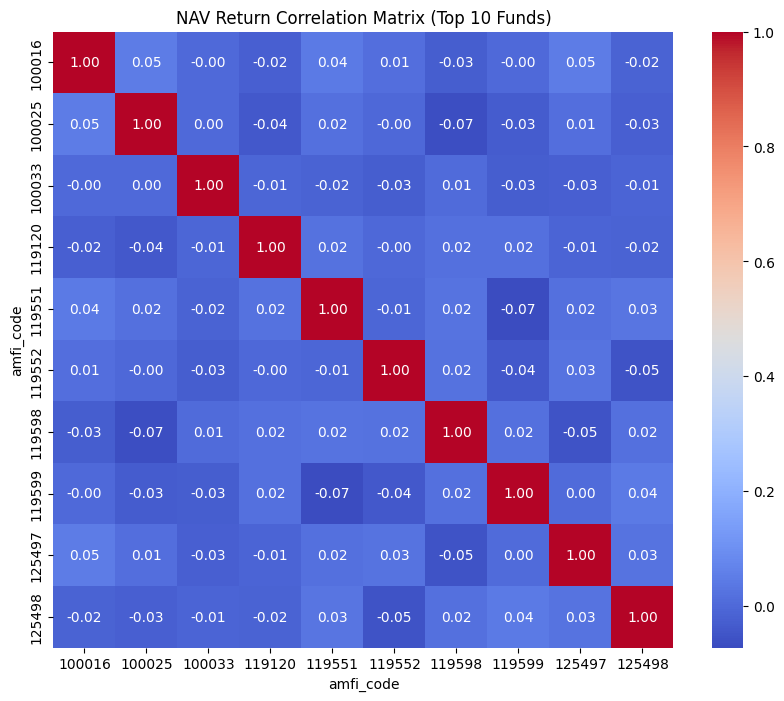

In [9]:
# 8. NAV return correlation matrix - compute pairwise correlation of daily returns for 10 selected funds. Seaborn heatmap.
# Get top 10 schemes by frequency in nav history
top_schemes = df_nav['amfi_code'].value_counts().head(10).index
df_nav_sub = df_nav[df_nav['amfi_code'].isin(top_schemes)]
pivot_nav = df_nav_sub.pivot(index='date', columns='amfi_code', values='nav')
returns = pivot_nav.pct_change().dropna()
corr = returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('NAV Return Correlation Matrix (Top 10 Funds)')
plt.savefig('../reports/figures/nav_correlation.png')
plt.show()


### Insight 9: Sector Concentration
Financials and IT remain the most heavily weighted sectors across equity mutual funds, reflecting their substantial role in the Indian market.
*(Supporting Chart: Sector Allocation Donut Chart)*

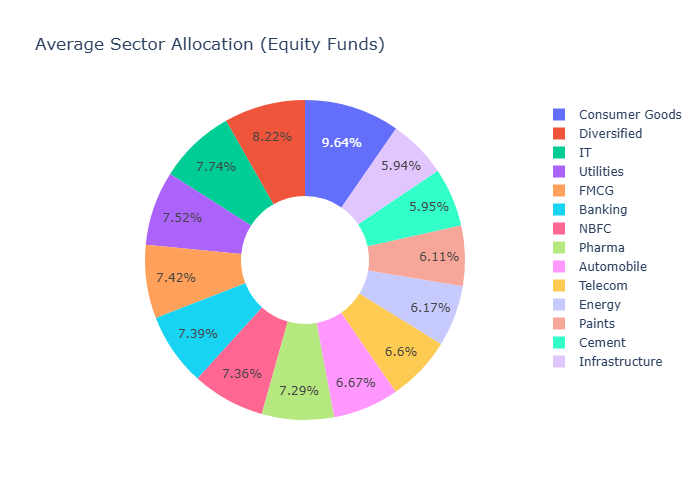

In [10]:
# 9. Sector allocation donut - aggregate sector weights from portfolio_holdings.csv across all equity funds.
df_hold = pd.read_csv(f'{DATA_DIR}/09_portfolio_holdings.csv')
if 'percentage_to_aum' in df_hold.columns:
    val_col = 'percentage_to_aum'
else:
    val_col = [c for c in df_hold.columns if 'percent' in c.lower() or 'weight' in c.lower()][0]
    
sector_weights = df_hold.groupby('sector')[val_col].mean().reset_index()
sector_weights = sector_weights[sector_weights['sector'] != 'Cash/Others']

fig = px.pie(sector_weights, names='sector', values=val_col, hole=0.4, title='Average Sector Allocation (Equity Funds)')
fig.write_image("../reports/figures/sector_allocation.png", engine="kaleido")
fig.show(renderer="png")


### Insight 10: Scheme Performance Distribution
A vast majority of schemes fall within the 10-15% CAGR bracket over 3-year periods, with only a select few consistently exceeding 20%.
*(Supporting Charts: CAGR Distribution, Benchmark Comparison & AUM Share by Category)*

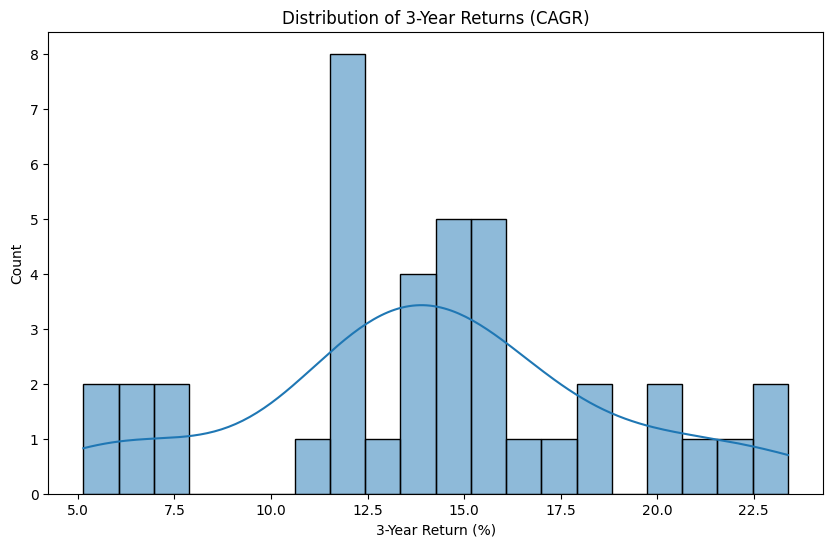

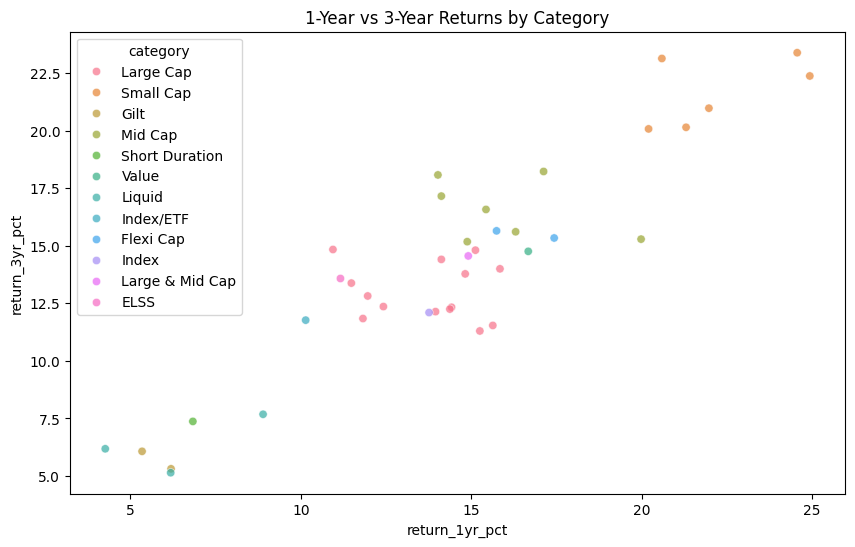

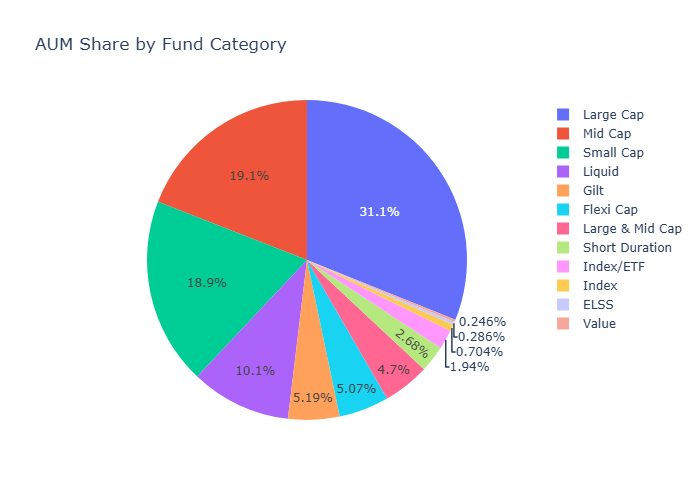

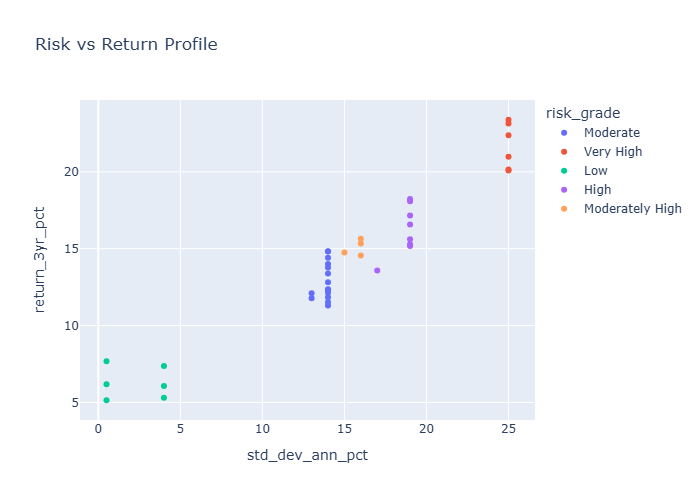

In [11]:
# 10. Additional EDA on scheme performance
df_perf = pd.read_csv(f'{DATA_DIR}/07_scheme_performance.csv')
plt.figure(figsize=(10, 6))
sns.histplot(df_perf['return_3yr_pct'].dropna(), bins=20, kde=True)
plt.title('Distribution of 3-Year Returns (CAGR)')
plt.xlabel('3-Year Return (%)')
plt.savefig('../reports/figures/returns_distribution.png')
plt.show()

# Extra Chart 1: Fund vs Benchmark
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_perf, x='return_1yr_pct', y='return_3yr_pct', hue='category', alpha=0.7)
plt.title('1-Year vs 3-Year Returns by Category')
plt.savefig('../reports/figures/returns_scatter.png')
plt.show()

# Extra Chart 2: Category AUM Distribution
fig_cat_aum = px.pie(df_perf, names='category', values='aum_crore', title='AUM Share by Fund Category')
fig_cat_aum.write_image("../reports/figures/category_aum_share.png", engine="kaleido")
fig_cat_aum.show(renderer="png")

# Extra Chart 3: Risk vs Return Scatter
fig_risk = px.scatter(df_perf, x='std_dev_ann_pct', y='return_3yr_pct', color='risk_grade', hover_name='scheme_name', title='Risk vs Return Profile')
fig_risk.write_image("../reports/figures/risk_vs_return.png", engine="kaleido")
fig_risk.show(renderer="png")
